# Brief Introduction to Pandas

- Provides a powerful `DataFrame` object.
- Makes it easy to deal with "Tabular" data.
- Very easy to read, process and visualize data.
- See http://pandas.pydata.org

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Fundamentals

- Why do we need this?
- Data is often **tabular**
  - Imagine the class marks in a course or during a program
  - Imagine a population with weight, height, age etc.

- Think of each student as a row
- Each column as an attribute
- So the columns are **aligned** using the row

- With `pandas`, data alignment is **central**

There are three fundamental building blocks in pandas:
1. `pd.Series`
2. `pd.DataFrame` and
3. `pd.Index`

We will look into the first two as they are the most important.

## Building block: `Series`

- "Labels" are collectively called the **index**
- `Series`: bundles together an index and values
- Index can be implicit or explicit


In [2]:
sn = pd.Series(np.random.normal(size=5))
sn

0   -1.207795
1    0.727872
2    0.459992
3   -0.232990
4    0.017316
dtype: float64

In [3]:
sn.values

array([-1.2077952 ,  0.72787223,  0.45999224, -0.23299012,  0.01731631])

In [4]:
sn.index

RangeIndex(start=0, stop=5, step=1)


The values attribute is a numpy array

The index is an instance of `pd.Index` which is another fundamental building
block.

In [5]:
sa = pd.Series(np.random.normal(size=5), index=["a", "b", "c", "d", "e"])
sa

a   -0.435767
b   -0.711876
c   -0.646327
d    1.614512
e    1.105614
dtype: float64

In [6]:
sn[0]

np.float64(-1.2077952033273582)

In [7]:
# Note the warning!
sa[0]

KeyError: 0

In [8]:
# This is the right way to access.
sa['a']

np.float64(-0.43576669944173346)

### `Series`: some points to note

- They behave like `numpy` arrays or dictionaries
- But carry the index
- All operations align on the label (i.e. index)
- The indices need not be contiguous or even be integers
- In a sense the `Series` is like a special dictionary keyed on index.
- Unaligned series will use the union of indices
- `NaN` is used to refer to missing values


In [9]:
# Can be initialized with a dictionary
a = pd.Series(dict(x=1, a=21, b=2))
a

x     1
a    21
b     2
dtype: int64

In [10]:
# Or with explicit values and indices
a = pd.Series(np.arange(5), index=range(100, 110, 2))
a

100    0
102    1
104    2
106    3
108    4
dtype: int64

In [11]:
a[102]

np.int64(1)

In [12]:
a = pd.Series(np.ones(5), index=["a", "b", "c", "d", "e"])
b = pd.Series(np.arange(5), index=["e", "d", "c", "b", "a"])
a + b

a    5.0
b    4.0
c    3.0
d    2.0
e    1.0
dtype: float64

In [13]:
a.dtype

dtype('float64')

In [14]:
a = pd.Series(np.ones(5), index=["a", "b", "c", "d", "e"])
b = pd.Series(np.arange(4), index=["e", "d", "c", "b"])
a + b

a    NaN
b    4.0
c    3.0
d    2.0
e    1.0
dtype: float64

### Aside

- `NaN` is a number!
- Beware of them
- Used to denote missing values in pandas.

In [15]:
float('nan'), float('NaN')

(nan, nan)

In [16]:
type(float('nan'))

float

In [17]:
np.nan

nan

In [18]:
np.nan + 1

nan

In [19]:
x = np.arange(5, dtype=float)
np.sum(x), np.mean(x)

(np.float64(10.0), np.float64(2.0))

In [20]:
x[0] = np.nan
np.sum(x), np.mean(x)

(np.float64(nan), np.float64(nan))

- Use `np.nan*` functions
- `np.isnan` is also handy


In [21]:
print(x)
print(np.sum(x))
np.nansum(x), np.nanmean(x)

[nan  1.  2.  3.  4.]
nan


(np.float64(10.0), np.float64(2.5))

## `DataFrame` basics

- A table of data: a spreadsheet
- Same index for all columns
- Different data types per column
- Think of it as a 2D numpy array with flexible row and column names.

We can construct these using Series objects.

In [22]:
state_pop = {'Maharashtra': 112374333, 'UP': 199812341, 'Bihar': 104099452,
             'West Bengal': 91276115, 'MP': 72626809}
pop = pd.Series(state_pop)
pop

Maharashtra    112374333
UP             199812341
Bihar          104099452
West Bengal     91276115
MP              72626809
dtype: int64

In [23]:
state_area = {'MP': 308252,  'UP': 240928, 'Maharashtra': 307713, 'Bihar': 94163,
              'West Bengal': 88752}
area = pd.Series(state_area)
area

MP             308252
UP             240928
Maharashtra    307713
Bihar           94163
West Bengal     88752
dtype: int64

In [24]:
states = pd.DataFrame({'population': pop, 'area': area})
states

,population,area
Bihar,104099452,94163
MP,72626809,308252
Maharashtra,112374333,307713
UP,199812341,240928
West Bengal,91276115,88752


In [25]:
states.index

Index(['Bihar', 'MP', 'Maharashtra', 'UP', 'West Bengal'], dtype='str')

In [26]:
states.columns

Index(['population', 'area'], dtype='str')

In [27]:
states['area']

Bihar           94163
MP             308252
Maharashtra    307713
UP             240928
West Bengal     88752
Name: area, dtype: int64

In [28]:
states['population']

Bihar          104099452
MP              72626809
Maharashtra    112374333
UP             199812341
West Bengal     91276115
Name: population, dtype: int64

In [29]:
states.area

Bihar           94163
MP             308252
Maharashtra    307713
UP             240928
West Bengal     88752
Name: area, dtype: int64


Can also create a data frame by supplying lists or numpy arrays

In [30]:
d = pd.DataFrame(dict(x=[1, 2, 3], y=['hello', 'class', '2025']))

In [31]:
d

,x,y
0,1,hello
1,2,class
2,3,2025


In [32]:
# Note that the index is implicit which may not be ideal
d.index

RangeIndex(start=0, stop=3, step=1)

In [33]:
d.describe()

,x
count,3.0
mean,2.0
std,1.0
min,1.0
25%,1.5
50%,2.0
75%,2.5
max,3.0


In [34]:
d.dtypes  # This is great for debugging if you run into errors.

x    int64
y      str
dtype: object

Can create the array with a two-dimensional numpy array

In [35]:
pd.DataFrame(np.random.rand(3, 2),
             columns=['x', 'y'],
             index=['a', 'b', 'c'])

,x,y
a,0.674227,0.533526
b,0.920457,0.049773
c,0.691067,0.544144


## The `pd.Index` object

Can be constructed explicitly

In [36]:
ind = pd.Index([2, 4, 6, 8, 10])
ind

Index([2, 4, 6, 8, 10], dtype='int64')

In [37]:
ind1 = pd.Index([2, 3, 5, 7, 11])


- The index is immutable
- Supports basic set-like operations
  - Union, `.union(...)`
  - Intersection, `.intersection(...)`

In [38]:
ind.union(ind1)

Index([2, 3, 4, 5, 6, 7, 8, 10, 11], dtype='int64')

In [39]:
ind.intersection(ind1)

Index([2], dtype='int64')

In [40]:
ind1.union(ind)

Index([2, 3, 4, 5, 6, 7, 8, 10, 11], dtype='int64')

### A toy example.

- This is a boring dataset but easy to create and demonstrate the basic
  features.

In [41]:
x = np.linspace(0, 2*np.pi, 100)
sin = np.sin(x)
cos = np.cos(x)

In [42]:
df = pd.DataFrame(dict(x=x, sin=sin))
df.head()

,x,sin
0,0.000000,0.000000
1,0.063467,0.063424
2,0.126933,0.126592
3,0.190400,0.189251
4,0.253866,0.251148


In [43]:
df = pd.DataFrame({'x': x, 'sin': sin, 'cos': cos, 'x-data':x})
# OR
#df = pd.DataFrame(dict(x=x, sin=sin, cos=cos))

In [44]:
df.head()  # or df.tail()

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866


In [45]:
df.tail()

,x,sin,cos,x-data
95,6.029319,-2.511480e-01,0.967949,6.029319
96,6.092786,-1.892512e-01,0.981929,6.092786
97,6.156252,-1.265925e-01,0.991955,6.156252
98,6.219719,-6.342392e-02,0.997987,6.219719
99,6.283185,-2.449294e-16,1.000000,6.283185


In [46]:
df.describe()

,x,sin,cos,x-data
count,100.000000,1.000000e+02,100.000000,100.000000
mean,3.141593,-2.243331e-17,0.010000,3.141593
std,1.841258,7.071068e-01,0.714143,1.841258
min,0.000000,-9.998741e-01,-0.999497,0.000000
25%,1.570796,-6.957328e-01,-0.701475,1.570796
50%,3.141593,-1.224647e-16,0.015858,3.141593
75%,4.712389,6.957328e-01,0.723734,4.712389
max,6.283185,9.998741e-01,1.000000,6.283185


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       100 non-null    float64
 1   sin     100 non-null    float64
 2   cos     100 non-null    float64
 3   x-data  100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


In [48]:
df['x-data']

0     0.000000
1     0.063467
2     0.126933
3     0.190400
4     0.253866
        ...   
95    6.029319
96    6.092786
97    6.156252
98    6.219719
99    6.283185
Name: x-data, Length: 100, dtype: float64

In [49]:
df[::10]

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
10,0.634665,0.592908,0.805270,0.634665
20,1.269330,0.954902,0.296920,1.269330
30,1.903996,0.945001,-0.327068,1.903996
40,2.538661,0.567060,-0.823677,2.538661
50,3.173326,-0.031728,-0.999497,3.173326
60,3.807991,-0.618159,-0.786053,3.807991
70,4.442656,-0.963842,-0.266474,4.442656
80,5.077321,-0.934148,0.356886,5.077321
90,5.711987,-0.540641,0.841254,5.711987


In [50]:
df.x[::10]

0     0.000000
10    0.634665
20    1.269330
30    1.903996
40    2.538661
50    3.173326
60    3.807991
70    4.442656
80    5.077321
90    5.711987
Name: x, dtype: float64

In [51]:
# df.x-data[:5] will not work!!
df['x-data'][:5]

0    0.000000
1    0.063467
2    0.126933
3    0.190400
4    0.253866
Name: x-data, dtype: float64

In [52]:
df['x'][:5]

0    0.000000
1    0.063467
2    0.126933
3    0.190400
4    0.253866
Name: x, dtype: float64

In [53]:
df.x[:10]

0    0.000000
1    0.063467
2    0.126933
3    0.190400
4    0.253866
5    0.317333
6    0.380799
7    0.444266
8    0.507732
9    0.571199
Name: x, dtype: float64

In [54]:
df.columns

Index(['x', 'sin', 'cos', 'x-data'], dtype='str')

In [55]:
# Very useful when reading a file to ensure that the types are correctly
# parsed.
df.dtypes

x         float64
sin       float64
cos       float64
x-data    float64
dtype: object

In [56]:
len(df)

100

In [57]:
df.index

RangeIndex(start=0, stop=100, step=1)

In [58]:
df1 = df.copy()
df1.head()

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866


Indexing
=========

Can do what we did above but also using:

- Select column: `df[col]`
- Slice rows: `df[3:13]`
- Select row by label: `df.loc[label_index]`
- Select row by numerical index: `df.iloc[integer]`
- Select rows by boolean vector: `df[bool_vec]`
- Select rows/colunns: `df[bool_vec, [label1, label2]]`
- `iloc`, `loc` are useful since using `[]` is confusing.

Shall explore this below.


In [59]:
df['x']  # Access a column

0     0.000000
1     0.063467
2     0.126933
3     0.190400
4     0.253866
        ...   
95    6.029319
96    6.092786
97    6.156252
98    6.219719
99    6.283185
Name: x, Length: 100, dtype: float64

In [60]:
df.loc[10]

x         0.634665
sin       0.592908
cos       0.805270
x-data    0.634665
Name: 10, dtype: float64

In [61]:
df.loc[:10]

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866
5,0.317333,0.312033,0.950071,0.317333
6,0.380799,0.371662,0.928368,0.380799
7,0.444266,0.429795,0.902927,0.444266
8,0.507732,0.486197,0.873849,0.507732
9,0.571199,0.540641,0.841254,0.571199


In [62]:
df.loc[:10, 'x']

0     0.000000
1     0.063467
2     0.126933
3     0.190400
4     0.253866
5     0.317333
6     0.380799
7     0.444266
8     0.507732
9     0.571199
10    0.634665
Name: x, dtype: float64

In [63]:
df.loc[:10, ['sin', 'cos']]

,sin,cos
0,0.000000,1.000000
1,0.063424,0.997987
2,0.126592,0.991955
3,0.189251,0.981929
4,0.251148,0.967949
5,0.312033,0.950071
6,0.371662,0.928368
7,0.429795,0.902927
8,0.486197,0.873849
9,0.540641,0.841254


In [64]:
# This is not different in this case as the indices are integers
# Better example below.
df.iloc[:10]

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866
5,0.317333,0.312033,0.950071,0.317333
6,0.380799,0.371662,0.928368,0.380799
7,0.444266,0.429795,0.902927,0.444266
8,0.507732,0.486197,0.873849,0.507732
9,0.571199,0.540641,0.841254,0.571199


### Examples with non-integer index


In [65]:
d = pd.DataFrame(dict(x=[1, 2, 3], y=['hello', 'class', '2021']), index=list('abc'))

In [66]:
d

,x,y
a,1,hello
b,2,class
c,3,2021


In [67]:
d.loc['a']

x        1
y    hello
Name: a, dtype: object

In [68]:
# Note that this includes the last slice label!
d.loc['a':'b']

,x,y
a,1,hello
b,2,class


In [69]:
d.iloc[0]

x        1
y    hello
Name: a, dtype: object

In [70]:
d[1:3]

,x,y
b,2,class
c,3,2021



Back to our original DataFrame, `df`
- Give me a dataframe, where all cosine values are >0.

In [71]:
df.head()

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866


In [72]:
# Recall masked indexing
y = np.linspace(10, 11, 11)
y

array([10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. ])

In [73]:
y > 10.5

array([False, False, False, False, False, False,  True,  True,  True,
        True,  True])

In [74]:
cond = y > 10.5
y[cond]

array([10.6, 10.7, 10.8, 10.9, 11. ])

- Same thing works with pandas

In [75]:
condition = df.cos > 0.0
print(len(condition))
print(condition.sum())

100
50


In [76]:
df_positive_cos = df[condition]
df_positive_cos.describe()

,x,sin,cos,x-data
count,50.000000,5.000000e+01,50.000000,50.000000
mean,3.141593,5.093420e-18,0.650280,3.141593
std,2.448204,7.034880e-01,0.306625,2.448204
min,0.000000,-9.988673e-01,0.047582,0.000000
25%,0.777465,-6.782562e-01,0.415415,0.777465
50%,3.141593,-1.224647e-16,0.723734,3.141593
75%,5.505720,6.782562e-01,0.928368,5.505720
max,6.283185,9.988673e-01,1.000000,6.283185


In [77]:
# Combining conditionals
cond1 = df.sin > 0.0
df_all_positive = df[condition & cond1]
df_all_positive.describe()

,x,sin,cos,x-data
count,24.000000,24.000000,24.000000,24.000000
mean,0.793331,0.645876,0.635708,0.793331
std,0.448776,0.303115,0.307590,0.448776
min,0.063467,0.063424,0.047582,0.063467
25%,0.428399,0.415262,0.400783,0.428399
50%,0.793331,0.712335,0.701122,0.793331
75%,1.158264,0.915761,0.909287,1.158264
max,1.523196,0.998867,0.997987,1.523196


In [78]:
# Always, always use brackets when combining conditionals with bitwise
# operations.
df_all_positive = df[(df.cos > 0.0) & (df.sin > 0)]
df_all_positive.describe()

,x,sin,cos,x-data
count,24.000000,24.000000,24.000000,24.000000
mean,0.793331,0.645876,0.635708,0.793331
std,0.448776,0.303115,0.307590,0.448776
min,0.063467,0.063424,0.047582,0.063467
25%,0.428399,0.415262,0.400783,0.428399
50%,0.793331,0.712335,0.701122,0.793331
75%,1.158264,0.915761,0.909287,1.158264
max,1.523196,0.998867,0.997987,1.523196


In [79]:
# Use ~ for inverting the boolean as a Not
c = np.array([True, False, True, False])
c1 = np.array([False, True, False, False])
~(c | c1)

array([False, False, False,  True])

In [80]:
cond1 = df_positive_cos.sin > 0.0
df_all_positive = df_positive_cos[cond1]
df_all_positive.describe()

,x,sin,cos,x-data
count,24.000000,24.000000,24.000000,24.000000
mean,0.793331,0.645876,0.635708,0.793331
std,0.448776,0.303115,0.307590,0.448776
min,0.063467,0.063424,0.047582,0.063467
25%,0.428399,0.415262,0.400783,0.428399
50%,0.793331,0.712335,0.701122,0.793331
75%,1.158264,0.915761,0.909287,1.158264
max,1.523196,0.998867,0.997987,1.523196


In [81]:
# This adds a new column sincos
df['sincos'] = df.sin*df.cos
# Do not use df.sincos = ...
len(df.sincos)

100

In [82]:
df.describe()

,x,sin,cos,x-data,sincos
count,100.000000,1.000000e+02,100.000000,100.000000,1.000000e+02
mean,3.141593,-2.243331e-17,0.010000,3.141593,-2.865627e-18
std,1.841258,7.071068e-01,0.714143,1.841258,3.535534e-01
min,0.000000,-9.998741e-01,-0.999497,0.000000,-4.999371e-01
25%,1.570796,-6.957328e-01,-0.701475,1.570796,-3.478664e-01
50%,3.141593,-1.224647e-16,0.015858,3.141593,-1.224647e-16
75%,4.712389,6.957328e-01,0.723734,4.712389,3.478664e-01
max,6.283185,9.998741e-01,1.000000,6.283185,4.999371e-01


In [83]:
'x-data' in df

True

In [84]:
if 'x-data' in df:
    del df['x-data']
df.head()

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


### Operations and index alignment

- NumPy ufuncs can be applied
- All binary operations align on the index

In [85]:
d = pd.DataFrame(np.random.randint(0, 10, size=(3, 4)),
                 columns=['A', 'B', 'C', 'D'])
d

,A,B,C,D
0,4,7,8,4
1,5,3,4,9
2,1,4,8,8


In [86]:
np.sin(d)

,A,B,C,D
0,-0.756802,0.656987,0.989358,-0.756802
1,-0.958924,0.141120,-0.756802,0.412118
2,0.841471,-0.756802,0.989358,0.989358


In [87]:
a = pd.DataFrame(np.random.randint(0, 20, (2, 2)),
                 columns=list('AB'))
a

,A,B
0,6,14
1,14,9


In [88]:
b = pd.DataFrame(np.random.randint(0, 10, (3, 3)),
                 columns=list('BAC'))
b

,B,A,C
0,3,6,1
1,9,5,7
2,8,8,8


In [89]:
a + b  # Creates a new data frame.

,A,B,C
0,12.0,17.0,NaN
1,19.0,18.0,NaN
2,NaN,NaN,NaN


In [90]:
a.add(b, fill_value=0.0)  # Inplace addition
a

,A,B
0,6,14
1,14,9


There are many other methods, `sub, mul, floordiv, div, pow`, etc.

### Missing values
- Nan used to deal with missing values
- None also used to deal with missing values in data of type `object`

In [91]:
s = pd.Series([1, np.nan, 'hello', None])
s

0        1
1      NaN
2    hello
3     None
dtype: object

In [92]:
s.isnull()

0    False
1     True
2    False
3     True
dtype: bool

In [93]:
s.notnull()

0     True
1    False
2     True
3    False
dtype: bool

In [94]:
s.dropna()

0        1
2    hello
dtype: object

In [95]:
# See the various arguments for each of these methods
s.fillna(0)

0        1
1        0
2    hello
3        0
dtype: object

### Assignment of values

When assigning values, do it directly using `.loc`

In [96]:
# Recall this
d

,A,B,C,D
0,4,7,8,4
1,5,3,4,9
2,1,4,8,8


In [97]:
d[d.A > 5]

,A,B,C,D


In [98]:
# Note the warning!
d[d.A > 5]['A'] = 25
d

/var/folders/wp/th3b19fs1lj592c5288s9htm0000gn/T/ipykernel_21566/2088146002.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  d[d.A > 5]['A'] = 25


,A,B,C,D
0,4,7,8,4
1,5,3,4,9
2,1,4,8,8


In [99]:
# Instead do this:
d.loc[d.A > 5, 'A'] = 25
d

,A,B,C,D
0,4,7,8,4
1,5,3,4,9
2,1,4,8,8


- Always beware of this SettingWithCopyWarning warnings
- Avoid ever setting values on slices/subsets without due care.

### String processing

- For any string type, use the `str` attributes and its methods.
- This applies to `Series`, `Index` and `DataFrame` objects!

In [100]:
# From the pandas documentation.
s = pd.Series(
    ["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"], dtype="string"
)

In [101]:
s.str.lower()

0       a
1       b
2       c
3    aaba
4    baca
5    <NA>
6    caba
7     dog
8     cat
dtype: string

In [102]:
s.str.upper()

0       A
1       B
2       C
3    AABA
4    BACA
5    <NA>
6    CABA
7     DOG
8     CAT
dtype: string

In [103]:
s.str.upper().str.replace('C', 'XX')

0        A
1        B
2       XX
3     AABA
4    BAXXA
5     <NA>
6    XXABA
7      DOG
8     XXAT
dtype: string

Plotting
=========

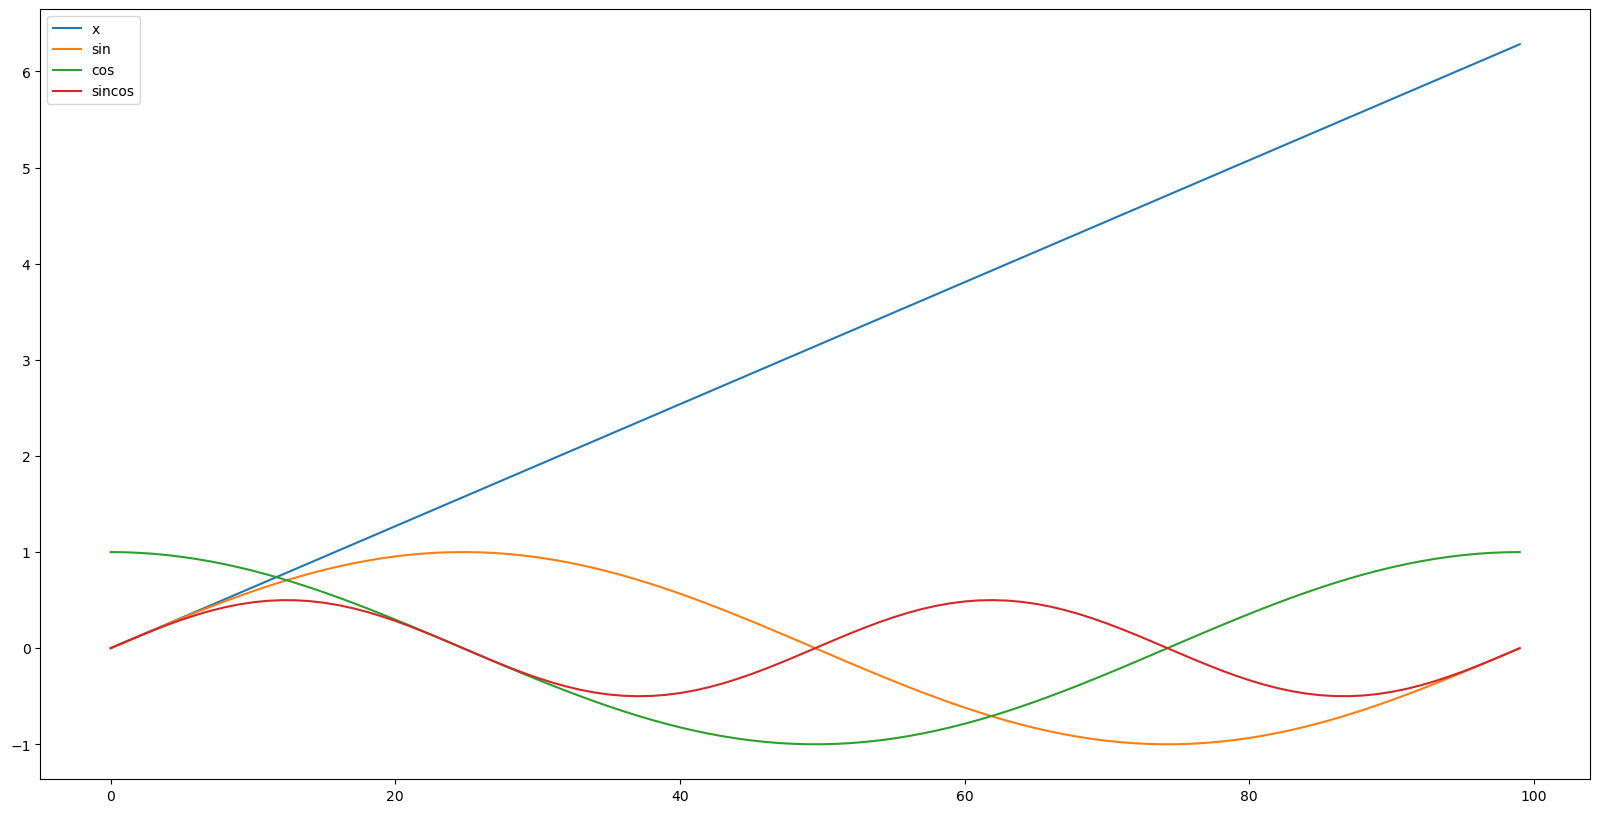

In [104]:
df.plot(figsize=(20, 10));
# or
#df.plot.line()

Notice that everything is plotted w.r.t. the index!
Let us fix this!

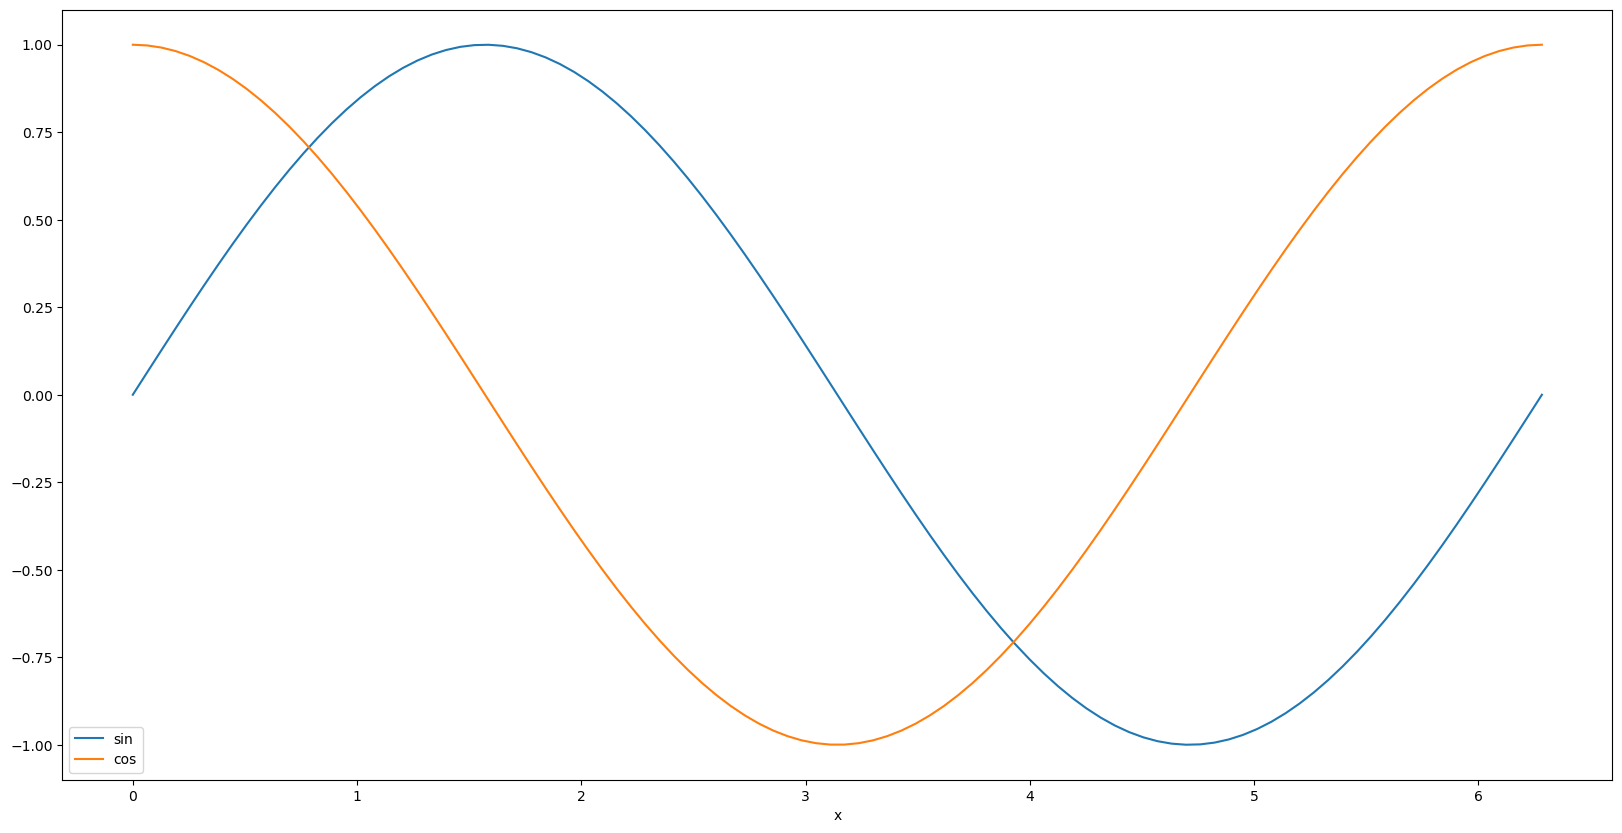

In [105]:
df.plot.line(x='x', y=['sin', 'cos'], figsize=(20, 10));

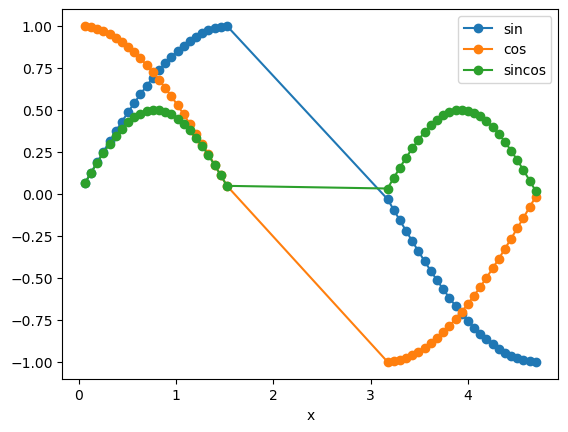

In [106]:
# See what this does
df[(df.sin > 0.0) ^ (df.cos < 0.0)].plot.line(x='x', marker='o');

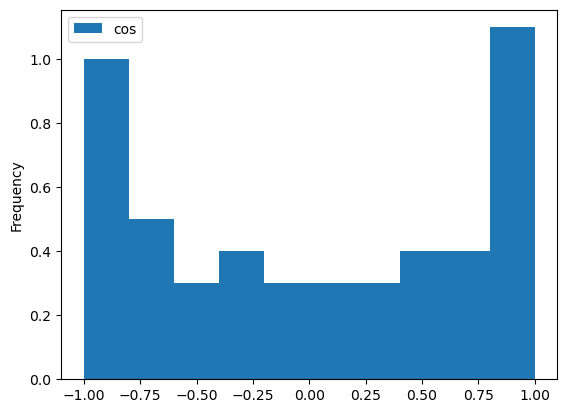

In [107]:
df.plot.hist(y='cos', density=True);
# or
#df.plot(y='cos', kind='hist');

Input and output CSV and other file formats
--------------------------------------------

- `pd.read_csv()`
- `df.to_csv()`
- Can read/save to clip board.
- Directly read from URLs.

In [108]:
df.to_csv('sincos.csv', index=False)

In [109]:
df1 = pd.read_csv('sincos.csv')
df1.head()

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


### Conversion to LaTeX and HTML

In [110]:
print(df[:5].to_latex())

\begin{tabular}{lrrrr}
\toprule
 & x & sin & cos & sincos \\
\midrule
0 & 0.000000 & 0.000000 & 1.000000 & 0.000000 \\
1 & 0.063467 & 0.063424 & 0.997987 & 0.063296 \\
2 & 0.126933 & 0.126592 & 0.991955 & 0.125574 \\
3 & 0.190400 & 0.189251 & 0.981929 & 0.185831 \\
4 & 0.253866 & 0.251148 & 0.967949 & 0.243098 \\
\bottomrule
\end{tabular}



In [111]:
print(df[:5].to_latex(index=False))

\begin{tabular}{rrrr}
\toprule
x & sin & cos & sincos \\
\midrule
0.000000 & 0.000000 & 1.000000 & 0.000000 \\
0.063467 & 0.063424 & 0.997987 & 0.063296 \\
0.126933 & 0.126592 & 0.991955 & 0.125574 \\
0.190400 & 0.189251 & 0.981929 & 0.185831 \\
0.253866 & 0.251148 & 0.967949 & 0.243098 \\
\bottomrule
\end{tabular}



In [112]:
print(df[:5].to_html())

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>x</th>
      <th>sin</th>
      <th>cos</th>
      <th>sincos</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>1.000000</td>
      <td>0.000000</td>
    </tr>
    <tr>
      <th>1</th>
      <td>0.063467</td>
      <td>0.063424</td>
      <td>0.997987</td>
      <td>0.063296</td>
    </tr>
    <tr>
      <th>2</th>
      <td>0.126933</td>
      <td>0.126592</td>
      <td>0.991955</td>
      <td>0.125574</td>
    </tr>
    <tr>
      <th>3</th>
      <td>0.190400</td>
      <td>0.189251</td>
      <td>0.981929</td>
      <td>0.185831</td>
    </tr>
    <tr>
      <th>4</th>
      <td>0.253866</td>
      <td>0.251148</td>
      <td>0.967949</td>
      <td>0.243098</td>
    </tr>
  </tbody>
</table>


In [113]:
from IPython.display import HTML
HTML(df[:5].to_html())

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


Selecting from the clipboard
=============================

- Let us select data from our previous sincos data frame.
- Will use this for more interesting stuff.

Select some data and then do this:


In [114]:
df2 = pd.read_clipboard()
df2

,Pandas.ipynb


In [115]:
url = 'https://drive.google.com/uc?id=1VgrBnWERE9YLslOoCLu8ZFLRbUu4jOED'
df = pd.read_csv(url, sep=';')

In [116]:
df.head()

,region,roll_number,name,fl,sl,math,sci,ss,total,pass,withheld,extra
0,A,10001,T N,53,36,28,16,44,177,NaN,NaN,NaN
1,A,10002,A R,58,37,42,35,40,212,P,NaN,NaN
2,A,10003,A M,72,56,71,55,70,324,P,NaN,NaN
3,A,10004,S A,87,64,83,58,65,357,P,NaN,NaN
4,A,10005,N A,59,45,50,35,48,237,P,NaN,NaN


In [117]:
df.describe()

,roll_number,fl,sl,math,sci,ss,total,withheld,extra
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,0.0,0.0
mean,27708.800000,72.725000,56.375000,65.425000,51.825000,63.500000,309.850000,NaN,NaN
std,29338.523097,12.858176,15.903052,23.915329,18.092196,17.558693,81.745869,NaN,NaN
min,10001.000000,43.000000,36.000000,25.000000,16.000000,35.000000,161.000000,NaN,NaN
25%,19495.750000,64.250000,44.000000,44.750000,36.750000,50.000000,247.000000,NaN,NaN
50%,27395.500000,75.000000,53.500000,61.500000,52.000000,61.500000,304.000000,NaN,NaN
75%,29276.250000,82.000000,70.250000,86.750000,60.250000,74.500000,357.000000,NaN,NaN
max,199976.000000,90.000000,90.000000,100.000000,86.000000,97.000000,456.000000,NaN,NaN


## Example: Getting Kohli's batting scores

- Obtaining the Batting score data for ODIs.
- We walk through how we get the data for V. Kohli
- First visit here: https://stats.espncricinfo.com/ci/engine/player/253802.html?class=2;template=results;type=batting;view=innings

In [118]:
df = pd.read_clipboard()
r = df.Runs.str.replace('*', '')
r1 = r[~r.str.contains('DNB')]
np.savetxt('/tmp/kohli.txt', r1.to_numpy(dtype=np.int32), fmt='%d')

AttributeError: 'DataFrame' object has no attribute 'Runs'

## Example: Getting all Kohli's ODI batting data

- Obtaining all available data
- First visit here: https://stats.espncricinfo.com/ci/engine/player/253802.html?class=2;template=results;type=batting;view=innings

In [119]:
data = pd.read_clipboard()

In [120]:
# Strip any leading/trailing whitespace from the column headers.
data.columns

Index(['Pandas.ipynb'], dtype='str')

In [121]:
data.columns = data.columns.str.strip()

In [122]:
# Remove columns that are completely empty or were artifacts of the import
# process.
unnamed_cols = [col for col in data.columns if "Unnamed" in col]

# The above is a list comprehension. Equivalent to the following.
unnamed_cols = []
for col in data.columns:
    if "Unnamed" in col:
        unnamed_cols.append(col)

# Now drop the columns
data = data.drop(columns=unnamed_cols)

In [123]:
# The 'Runs' column contains non-numeric characters like '*' for not-out
# innings. This section removes them and converts the column to a numeric type.
data["Runs"] = (
    data["Runs"].str
    .replace("*", "", regex=False).str
    .replace("DNB", np.nan)  # Replace 'Did Not Bat' with NaN
)
data["Runs"] = pd.to_numeric(data["Runs"], errors="coerce")

KeyError: 'Runs'

In [124]:
data.dtypes

Pandas.ipynb    object
dtype: object

In [125]:
# Convert the 'Start DateAscending' column to datetime objects.
# Then, create a 'Year' column and drop the original date column.
data["Date"] = pd.to_datetime(data["Start DateAscending"], errors="coerce")
data["Year"] = data["Date"].dt.year
data = data.drop(columns=["Start DateAscending"])

# Remove the "v " prefix from the 'Opposition' column for consistency.
data["Opposition"] = data["Opposition"].str.replace("v ", "", regex=False)

KeyError: 'Start DateAscending'

In [126]:
# Clean up text columns and create a binary 'NotOut' column.
data["Dismissal"] = (
    data["Dismissal"]
    .fillna("DNB")
    .astype(str)
    .str.strip()
    .fillna("DNB")
)
data["Ground"] = data["Ground"].str.strip()
data["Opposition"] = data["Opposition"].str.strip()
data["NotOut"] = data["Dismissal"].eq("not out").astype(int)

# Convert several other columns to numeric, coercing errors to NaN.
cols_to_numeric = ["BF", "4s", "6s", "Pos", "Inns", "SR", "Mins"]
for col in cols_to_numeric:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Arrange the DataFrame columns in a more logical order.
final_column_order = [
    "Date", "Year", "Ground", "Opposition", "Inns", "Pos",
    "Runs", "BF", "4s", "6s", "SR", "Dismissal", "NotOut"
]
data = data[final_column_order]
data.info()

# Export the final, cleaned DataFrame to a new CSV file.
output_filename = "/tmp/kohli_cleaned_batting.csv"
data.to_csv(output_filename, index=False)

KeyError: 'Dismissal'

### Some useful methods


In [127]:
(data.Runs > 100).value_counts()

AttributeError: 'DataFrame' object has no attribute 'Runs'

In [128]:
data.NotOut.value_counts()

AttributeError: 'DataFrame' object has no attribute 'NotOut'

In [129]:
np.sum(data.NotOut)

AttributeError: 'DataFrame' object has no attribute 'NotOut'

In [130]:
data.Opposition.value_counts()

AttributeError: 'DataFrame' object has no attribute 'Opposition'

In [131]:
data.Dismissal.value_counts()

AttributeError: 'DataFrame' object has no attribute 'Dismissal'

In [132]:
data.groupby('Opposition')['Runs'].sum()

KeyError: 'Opposition'

In [ ]:
data.groupby('Opposition')['Runs'].mean()

In [133]:
data.SR.mean()

AttributeError: 'DataFrame' object has no attribute 'SR'

In [134]:
data.groupby('Opposition')['SR'].mean()

KeyError: 'Opposition'

### Sampling a dataset

- Useful for probabilistic programming/bootstrapping

In [135]:
data.sample(5, replace=True)

ValueError: a must be greater than 0 unless no samples are taken

### Exercise


Consider a smaller file:

- File is at: http://www.aero.iitb.ac.in/~prabhu/tmp/sslc_small.csv
- Also in the files section


In [ ]:
url = 'http://www.aero.iitb.ac.in/~prabhu/tmp/sslc_small.csv'
df = pd.read_csv(url)
df.head()  # Produces only one strange column of data!

In [ ]:
df.dtypes

Notice that this data is read incorrectly, this is because the separator is
not a comma but a ';' so use this.

In [ ]:
df = pd.read_csv(url, sep=';')
df.head()

In [ ]:
df.dtypes

In [ ]:
df['region'].value_counts()

In [ ]:
df.plot.scatter(x='fl', y='math');

There are more options to `pd.read_csv`, for example if `'AA'` is a value
indicating a non-existing value you can pass an option, called `na_values`.
Read more on the documentation for `read_csv`.

In [ ]:
url = 'http://www.aero.iitb.ac.in/~prabhu/tmp/sslc1.csv.gz'
df = pd.read_csv(url, sep=';', na_values='AA')
df.head()

In [ ]:
df.dtypes

In [ ]:
df.describe()

In [ ]:
df.plot.hist(y='math', bins=50, figsize=(20, 10));

In [ ]:
data.groupby('Opposition')['Runs'].mean().plot.bar()
plt.tight_layout()
plt.grid();

More information
==================

- Only scratched the surface.
- http://pandas.pydata.org

- Go through the chapter here: https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html

- Go through the nice tutorials here:
   http://nbviewer.jupyter.org/github/jvns/pandas-cookbook/tree/v0.1/cookbook/